# 03 - Exploratory Data Analysis

This notebook explores the cleaned dataset to understand its structure, feature distributions, and key characteristics. The insights generated during this phase will guide feature engineering and model development.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## Load Clean Dataset

Load the validated dataset and remove duplicate records to ensure that all exploratory analyses are performed on the cleaned data.

In [2]:
DATA_PATH = Path("../data/raw/creditcard.csv")

df = pd.read_csv(DATA_PATH)

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataset Shape: {df.shape}")

Dataset Shape: (283726, 31)


## Dataset Overview

Review the overall structure of the dataset, including the number of rows, columns, and memory usage. This provides a high-level understanding before deeper analysis.

In [3]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.info()

Rows    : 283726
Columns : 31
<class 'pandas.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  floa

## First Five Records

Inspect the first few records to verify the dataset structure and understand how the features are organized.

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Statistical Summary

Generate descriptive statistics for all numerical features to understand their central tendency, spread, and overall distribution.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


## Dataset Dimensions Summary

Summarize the basic characteristics of the dataset in a concise table for quick reference.

In [6]:
overview = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Numeric Features",
        "Duplicate Records Removed",
        "Missing Values"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.select_dtypes(include="number").shape[1],
        1081,
        df.isnull().sum().sum()
    ]
})

overview

,Metric,Value
0,Rows,283726
1,Columns,31
2,Numeric Features,31
3,Duplicate Records Removed,1081
4,Missing Values,0


## Key Observations

- The dataset contains only numerical features.
- PCA-transformed features preserve privacy while retaining useful information.
- No missing values are present after cleaning.
- Duplicate records have been removed.
- The dataset is ready for detailed exploratory analysis.

## Univariate Analysis

Examine individual features to understand their distributions, variability, and overall characteristics. This analysis helps identify skewness, concentration, and potential anomalies before feature engineering.

In [7]:
plt.style.use("default")

## Transaction Amount Distribution

Visualize the distribution of transaction amounts to understand spending patterns and identify the presence of high-value transactions.

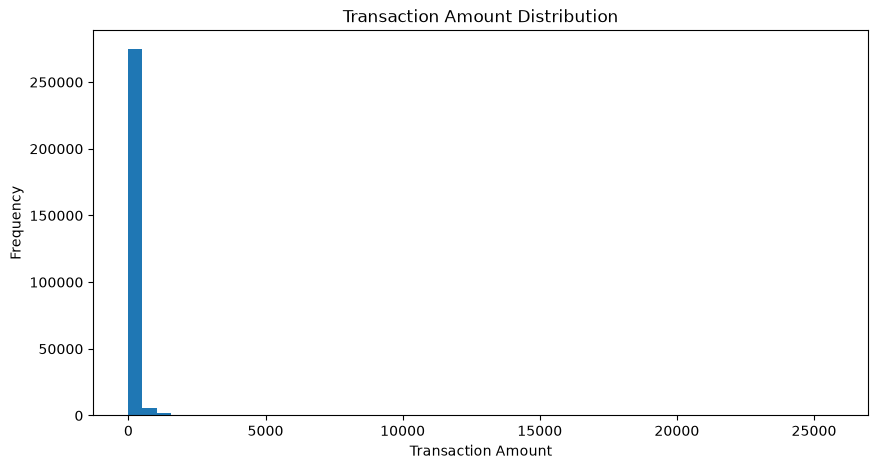

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

## Transaction Time Distribution

Analyze how transactions are distributed over time. The `Time` feature represents the elapsed time (in seconds) since the first transaction in the dataset.

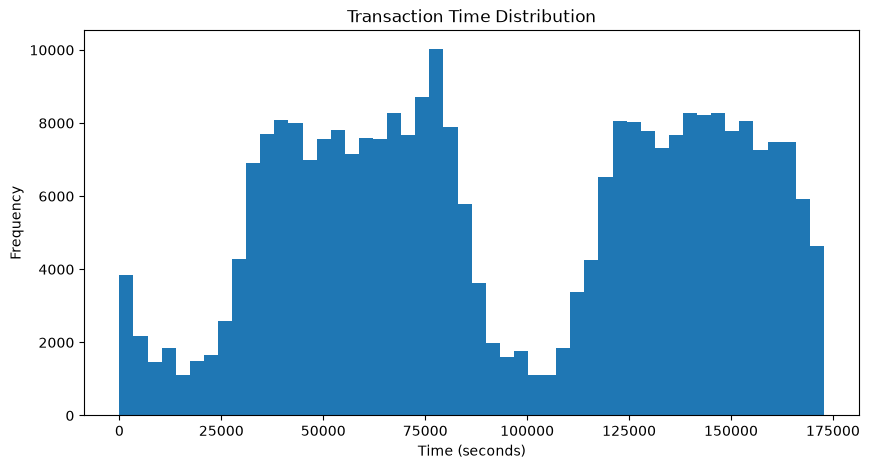

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(df["Time"], bins=50)

plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

plt.show()

## Class Distribution

Examine the frequency of legitimate and fraudulent transactions to understand the degree of class imbalance.

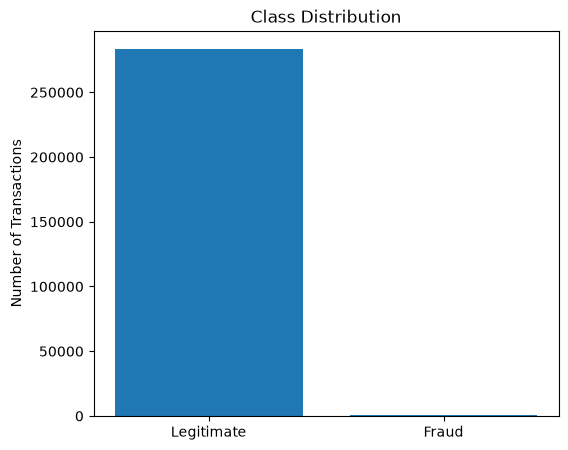

In [10]:
class_counts = (
    df["Class"]
    .value_counts()
    .sort_index()
)

labels = ["Legitimate", "Fraud"]

plt.figure(figsize=(6, 5))

plt.bar(labels, class_counts.values)

plt.title("Class Distribution")
plt.ylabel("Number of Transactions")

plt.show()

## PCA Feature Summary

Review descriptive statistics for the anonymized PCA features. These transformed variables cannot be interpreted individually but are important inputs for model training.

In [11]:
pca_summary = df.loc[:, "V1":"V28"].describe().T

pca_summary

,count,mean,std,min,25%,50%,75%,max
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995
V10,283726.0,-0.001441,1.076407,-24.588262,-0.535578,-0.093237,0.453619,23.745136


## Key Observations

- Transaction amounts are heavily right-skewed, with most transactions involving relatively small amounts.
- Transactions occur throughout the recorded time period without obvious gaps.
- Fraudulent transactions represent only a very small fraction of the dataset, indicating a severe class imbalance.
- PCA-transformed features are centered around zero with varying levels of dispersion, which is expected after Principal Component Analysis.

## Bivariate Analysis

Analyze the relationship between important features and the target variable. This helps identify patterns that distinguish legitimate transactions from fraudulent ones.

## Transaction Amount by Class

Compare the distribution of transaction amounts for legitimate and fraudulent transactions using box plots.

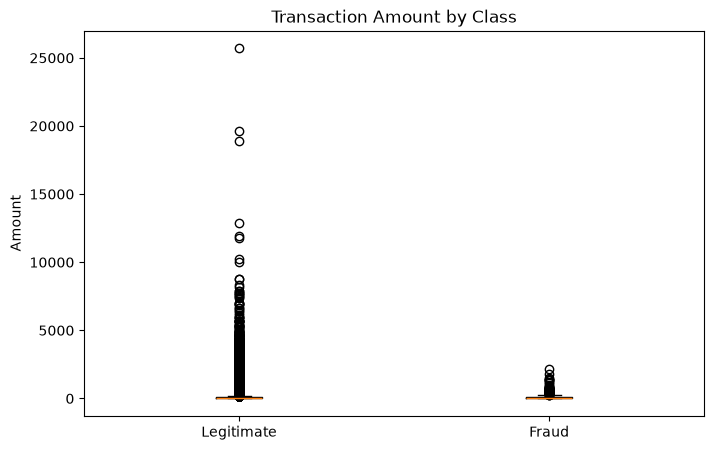

In [12]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Class"] == 0]["Amount"],
        df[df["Class"] == 1]["Amount"]
    ],
    tick_labels=["Legitimate", "Fraud"]
)

plt.title("Transaction Amount by Class")
plt.ylabel("Amount")

plt.show()

## Transaction Time by Class

Compare the distribution of transaction times for legitimate and fraudulent transactions.

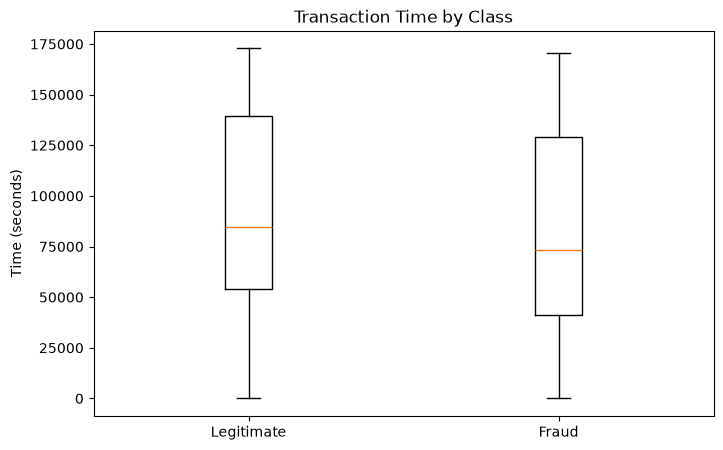

In [13]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["Class"] == 0]["Time"],
        df[df["Class"] == 1]["Time"]
    ],
    tick_labels=["Legitimate", "Fraud"]
)

plt.title("Transaction Time by Class")
plt.ylabel("Time (seconds)")

plt.show()

## Mean Feature Comparison

Compare the average values of the PCA-transformed features for legitimate and fraudulent transactions. Differences between the two classes may indicate features that are useful for classification.

In [14]:
feature_means = (
    df.groupby("Class")
      .mean(numeric_only=True)
      .T
)

feature_means.columns = ["Legitimate", "Fraud"]

feature_means.head()

,Legitimate,Fraud
Time,94835.058093,80450.513742
V1,0.013439,-4.498280
V2,-0.009829,3.405965
V3,0.012853,-6.729599
V4,-0.010440,4.472591


## Mean Comparison for PCA Features

Visualize the average values of the PCA features for both classes to identify features with noticeable differences.

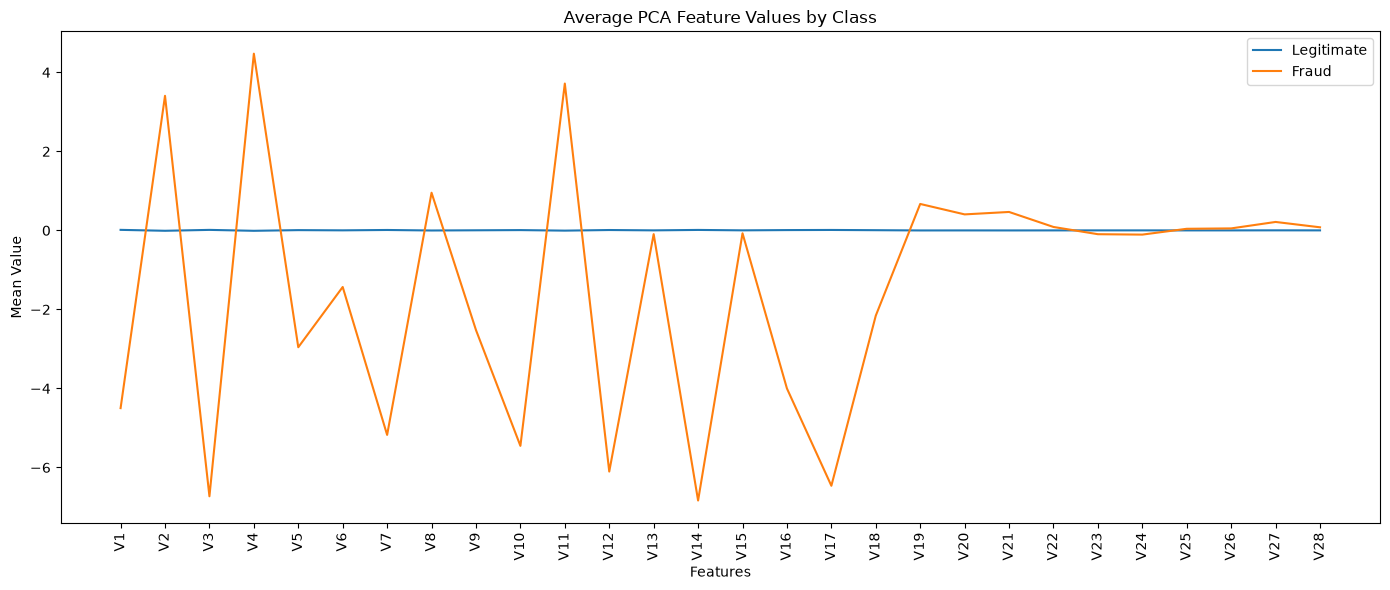

In [15]:
pca_means = feature_means.loc["V1":"V28"]

plt.figure(figsize=(14, 6))

plt.plot(
    pca_means.index,
    pca_means["Legitimate"],
    label="Legitimate"
)

plt.plot(
    pca_means.index,
    pca_means["Fraud"],
    label="Fraud"
)

plt.title("Average PCA Feature Values by Class")
plt.xlabel("Features")
plt.ylabel("Mean Value")

plt.legend()

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

## Key Observations

- Fraudulent transactions exhibit different patterns across several PCA features.
- Transaction amount distributions differ between legitimate and fraudulent transactions, although there is some overlap.
- Transaction time alone is not sufficient to distinguish fraudulent behavior.
- Multiple PCA features show clear separation between the two classes, suggesting they will be valuable for model training.

## Correlation Analysis

Analyze the relationships between numerical features using Pearson's correlation coefficient. Correlation analysis helps identify feature dependencies and provides insight into the overall structure of the dataset.

In [16]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,...,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,...,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,...,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,...,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,...,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326


## Correlation Heatmap

Visualize the correlation matrix to identify strongly correlated feature pairs. Since the dataset contains many numerical features, a heatmap provides an intuitive overview of feature relationships.

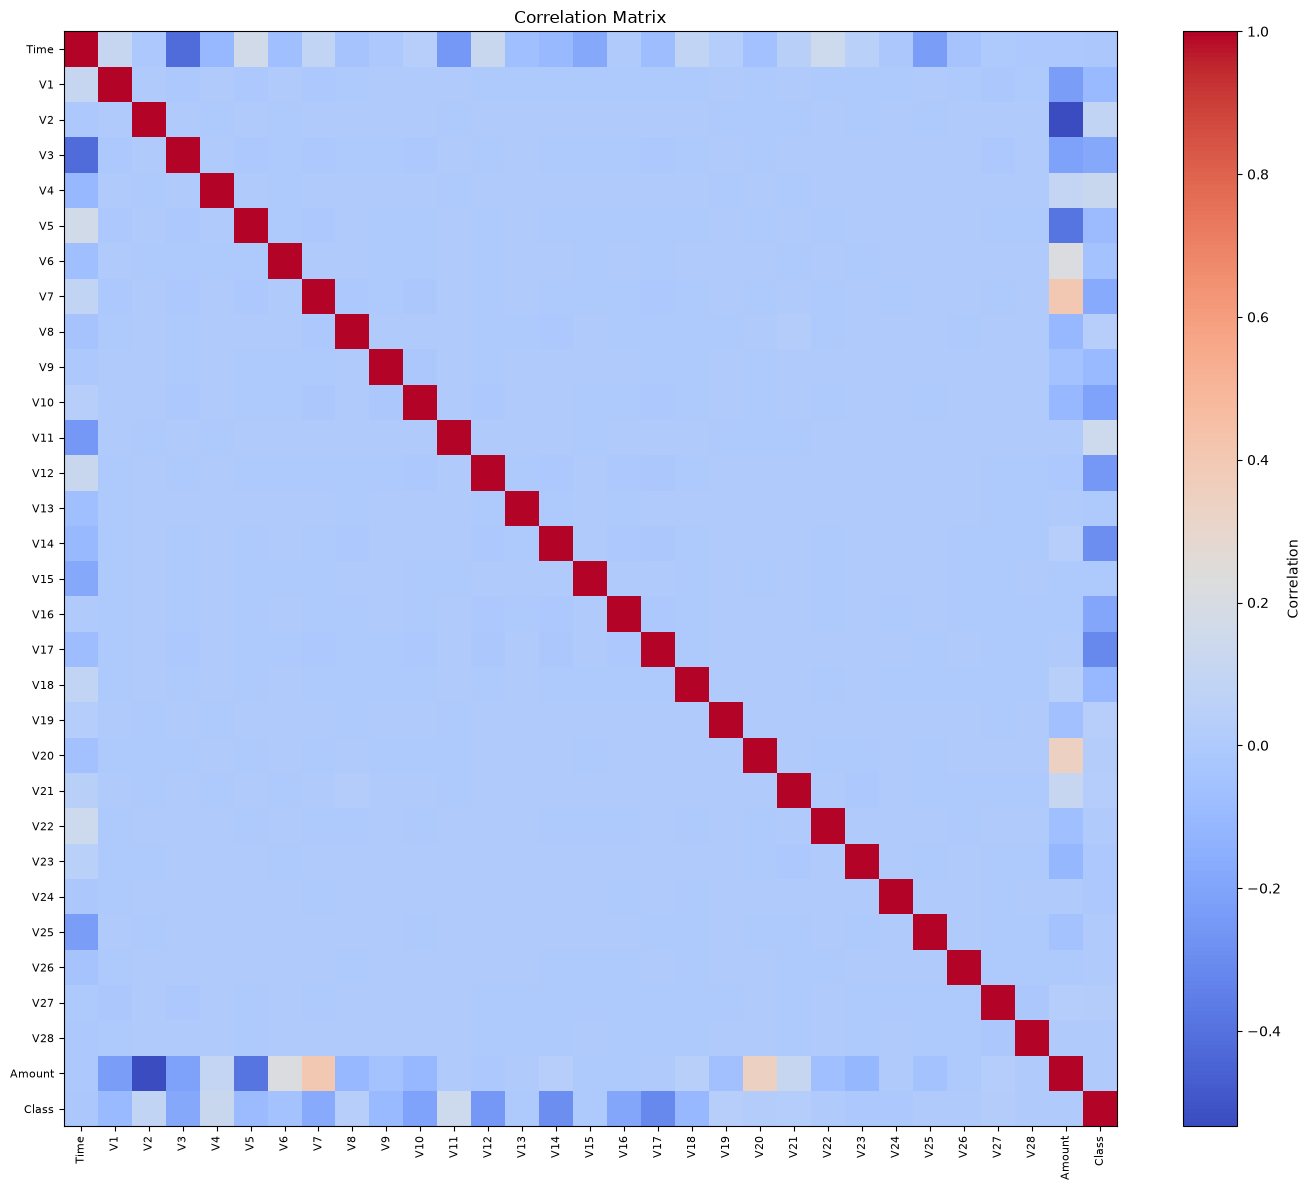

In [17]:
plt.figure(figsize=(14, 12))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    fontsize=8
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

## Features Most Correlated with the Target Variable

Identify the numerical features that have the strongest positive and negative correlation with the target variable (`Class`). These features may provide useful predictive information for fraud detection.

In [18]:
target_correlation = (
    correlation_matrix["Class"]
    .drop("Class")
    .sort_values(ascending=False)
)

target_correlation

V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64

## Top Correlated Features

Review the features with the strongest positive and negative correlation to the target variable.

In [19]:
print("Top Positive Correlations")
display(target_correlation.head(10))

print("\nTop Negative Correlations")
display(target_correlation.tail(10))

Top Positive Correlations


V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
Name: Class, dtype: float64


Top Negative Correlations


V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64

## Key Observations

- Most PCA-transformed features exhibit low pairwise correlation, which is expected because Principal Component Analysis produces nearly orthogonal components.
- Several features show stronger positive or negative correlations with the target variable, making them promising candidates for fraud detection models.
- No evidence of severe multicollinearity is observed among the majority of features.
- Correlation analysis provides an initial understanding of feature relationships but should not be used alone for feature selection.

## Target Distribution

Analyze the distribution of the target variable to understand the proportion of legitimate and fraudulent transactions. Since fraud detection is an imbalanced classification problem, this analysis guides the selection of suitable modeling and evaluation strategies.

In [20]:
target_counts = (
    df["Class"]
    .value_counts()
    .sort_index()
)

target_distribution = pd.DataFrame({
    "Class": ["Legitimate", "Fraud"],
    "Count": target_counts.values,
    "Percentage (%)": (
        target_counts.values / len(df) * 100
    ).round(4)
})

target_distribution

,Class,Count,Percentage (%)
0,Legitimate,283253,99.8333
1,Fraud,473,0.1667


## Target Class Distribution

Visualize the number of legitimate and fraudulent transactions using a bar chart.

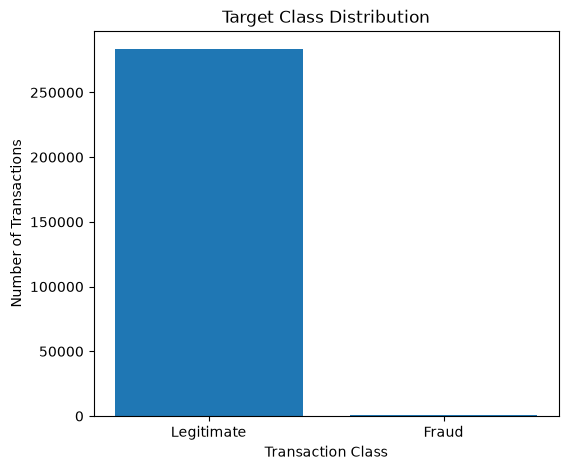

In [21]:
plt.figure(figsize=(6, 5))

plt.bar(
    target_distribution["Class"],
    target_distribution["Count"]
)

plt.title("Target Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

## Class Imbalance Ratio

Measure the imbalance between legitimate and fraudulent transactions. This ratio provides a clear indication of how challenging the classification task is.

In [22]:
legitimate = target_counts[0]
fraud = target_counts[1]

imbalance_ratio = legitimate / fraud

print(f"Legitimate Transactions : {legitimate:,}")
print(f"Fraud Transactions      : {fraud:,}")
print(f"Imbalance Ratio         : {imbalance_ratio:.2f} : 1")

Legitimate Transactions : 283,253
Fraud Transactions      : 473
Imbalance Ratio         : 598.84 : 1


## Modeling Implications

Interpret the target distribution and identify the considerations it introduces for model development.

In [23]:
print("Observations")
print("-" * 40)

print("• The dataset is highly imbalanced.")
print("• Accuracy alone is not an appropriate evaluation metric.")
print("• Precision, Recall, F1-Score, ROC-AUC and PR-AUC should be emphasized.")
print("• Class balancing techniques may improve model performance.")

Observations
----------------------------------------
• The dataset is highly imbalanced.
• Accuracy alone is not an appropriate evaluation metric.
• Precision, Recall, F1-Score, ROC-AUC and PR-AUC should be emphasized.
• Class balancing techniques may improve model performance.


## Key Observations

- Legitimate transactions dominate the dataset, while fraudulent transactions account for only a small percentage.
- The dataset exhibits a severe class imbalance, making fraud detection a challenging classification task.
- Model evaluation should prioritize Precision, Recall, F1-Score, ROC-AUC, and PR-AUC rather than relying solely on Accuracy.
- Class balancing techniques such as class weighting, undersampling, oversampling, or SMOTE can be explored during model development.

## Business Insights

Interpret the exploratory data analysis from a business perspective. These insights help stakeholders understand the characteristics of fraudulent transactions and guide the design of an effective fraud detection system.

## Key Business Findings

### 1. Fraud is Extremely Rare

Fraudulent transactions represent only a very small fraction of all transactions. A fraud detection system must therefore focus on identifying rare events without disrupting genuine customer activity.

---

### 2. Class Imbalance is a Business Challenge

Because legitimate transactions vastly outnumber fraudulent ones, predicting every transaction as legitimate would achieve high accuracy but provide no practical business value.

---

### 3. High-Value Transactions Require Attention

The transaction amount distribution indicates the presence of high-value transactions. These transactions should receive additional scrutiny because they can result in greater financial losses if fraudulent.

---

### 4. Fraud Patterns are Multi-Dimensional

Several PCA-transformed features differ noticeably between legitimate and fraudulent transactions. This suggests that fraud cannot be detected using a single rule and instead requires machine learning models capable of learning complex patterns.

---

### 5. Data Quality Supports Reliable Modeling

The dataset contains no missing values, no invalid values, and duplicate records have been removed. This provides a strong foundation for developing reliable machine learning models.

## Business Recommendations

- Deploy a real-time fraud detection system to evaluate transactions before approval.
- Prioritize minimizing false negatives to reduce financial losses caused by undetected fraud.
- Balance fraud prevention with customer experience by minimizing unnecessary false positives.
- Use probability scores from machine learning models to support risk-based transaction reviews.
- Continuously retrain the model with newly collected transaction data to adapt to evolving fraud patterns.

## EDA Conclusion

The exploratory data analysis confirms that the dataset is well-structured and suitable for fraud detection. The primary challenge is the severe class imbalance, while the PCA-transformed features provide meaningful discriminatory information. These findings establish a solid foundation for feature engineering, model development, and deployment of a production-ready fraud detection system.